# Project 5: W-Shape Tension Member Automation

**CIVE 202 | Group GEST-01-C**

**Jacob Oetken, Michael McCarthy, Tyler Thiede, Bryce Ripley**

This notebook performs automated tensile yielding checks for W-shape steel tension members using both **LRFD** and **ASD** design methods per AISC specifications. The user provides a W-shape designation, ASTM material grade, and applied loads. The code looks up the required section properties from CSV tables, computes capacities and demand-to-capacity ratios, and compares the user case against three additional design scenarios.

> **Required files:** `W_Shape_Table.csv` and `ASTM_Material_Fy_Table.csv` must be located in the **same folder** as this notebook for the file paths to resolve correctly.

## Import Libraries

Import all required Python libraries. `pandas` handles CSV data, `numpy` supports numeric operations, `matplotlib` and `seaborn` produce the output charts, and `dataclasses` provides structured input validation.

In [1]:
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
sns.set_theme(style="whitegrid")

## Design Constants

Three module-level constants control the design checks throughout the notebook:

- **`PHI_YIELDING = 0.90`** - LRFD resistance factor for tensile yielding per AISC Section D2(a)
- **`OMEGA_YIELDING = 1.67`** - ASD safety factor for tensile yielding per AISC Section D2(a)
- **`DEFAULT_ASTM = "A992"`** - Default material grade applied when the user leaves the material prompt blank; A992 is the standard grade for wide-flange sections

In [2]:
PHI_YIELDING   = 0.90   # φ: LRFD resistance factor for tensile yielding (AISC D2-1)
OMEGA_YIELDING = 1.67   # Ω: ASD safety factor for tensile yielding (AISC D2-2)
DEFAULT_ASTM   = "A992" # Default material grade when user leaves prompt blank


## DesignInput Dataclass

The `DesignInput` dataclass bundles all parameters for a single design scenario into one typed object. Using a dataclass enforces correct data types (strings for labels, floats for loads) and makes it easy to pass a scenario through multiple functions without long argument lists.

In [3]:
# DesignInput bundles all parameters for one scenario into a single typed object.
# Using a dataclass enforces string/float types and prevents silent type errors from raw CSV values being passed directly into arithmetic.
@dataclass
class DesignInput:
    scenario:        str    # Label used in the results table (e.g. "User Input")
    shape:           str    # W-shape designation (e.g. "W14X90")
    material:        str    # ASTM grade (e.g. "A992"); blank defaults to A992
    dead_load_kips:  float  # Dead load D (kips)
    live_load_kips:  float  # Live load L (kips)

## Tensile Yielding Check

`tensile_yielding_check` takes dead load `D`, live load `L`, yield stress `Fy`, and gross area `Ag` and returns a dictionary of all calculated design values.

**LRFD path:**
- Factored demand: `Pu = 1.2D + 1.6L`
- Available strength: `φPn = 0.90 × Fy × Ag`
- Utilization: `Pu / φPn × 100%`

**ASD path:**
- Service demand: `Pa = D + L`
- Allowable strength: `Pn / Ω = Fy × Ag / 1.67`
- Utilization: `Pa / (Pn/Ω) × 100%`

A utilization below 100% indicates the member passes; above 100% indicates failure.

In [4]:
#Compute LRFD and ASD tensile yielding demand, capacity, utilization, and pass/fail for one scenario.
def tensile_yielding_check(D: float, L: float, Fy: float, Ag: float) -> dict:

    # --- Demand ---
    Pu = 1.2 * D + 1.6 * L   # LRFD factored load (kips), AISC load combination
    Pa = D + L                 # ASD service load (kips)

    # --- Nominal and available strengths ---
    Pn     = Fy * Ag                 # Nominal tensile strength (kips): Pn = Fy × Ag
    phiPn  = PHI_YIELDING * Pn       # LRFD available strength: φPn (kips)
    Pallow = Pn / OMEGA_YIELDING     # ASD allowable strength: Pn/Ω (kips)

    # --- Utilization ratios (demand / capacity × 100%); values above 100% indicate failure ---
    u_lrfd = (Pu / phiPn) * 100      # LRFD utilization (%)
    u_asd  = (Pa / Pallow) * 100     # ASD utilization (%)

    return {
        "Pu (kips)":            Pu,
        "Pa (kips)":            Pa,
        "Pn (kips)":            Pn,
        "φPn (kips)":           phiPn,
        "Pn/Ω (kips)":          Pallow,
        "LRFD Utilization (%)": u_lrfd,
        "ASD Utilization (%)":  u_asd,
        "LRFD Pass":            "PASS" if phiPn >= Pu else "FAIL",
        "ASD Pass":             "PASS" if Pallow >= Pa else "FAIL",
    }

## Load W-Shape Table

`load_shape_table` reads `W_Shape_Table.csv` and returns a cleaned DataFrame with only two columns: `shape` (AISC designation) and `Ag` (gross cross-sectional area, in²). Shape labels are normalized to uppercase so lookups are case-insensitive.

In [ ]:
# Read W_Shape_Table.csv and return a cleaned DataFrame with columns: shape (AISC label) and Ag (in²).
def load_shape_table(csv_path: str) -> pd.DataFrame:
    # Read only the AISC label column (index 2) and gross area column (index 5): all others are ignored
    shapes = pd.read_csv(csv_path, usecols=[2, 5])
    shapes.columns = ["shape", "Ag"]
    shapes["shape"] = shapes["shape"].astype(str).str.strip().str.upper()  # Normalize for case-insensitive lookup
    shapes["Ag"]    = pd.to_numeric(shapes["Ag"], errors="coerce")          # Coerce non-numeric entries to NaN
    shapes = shapes.dropna(subset=["shape", "Ag"]).drop_duplicates(subset=["shape"])
    return shapes

## Load ASTM Material Table

`load_astm_table` reads `ASTM_Material_Fy_Table.csv` and returns a cleaned DataFrame with two columns: `material` (ASTM designation) and `Fy` (yield stress, ksi). Material labels are normalized to uppercase and `Fy` is coerced to a numeric float so it can be used directly in calculations.

In [6]:
# Read ASTM_Material_Fy_Table.csv and return a cleaned DataFrame with columns: material and Fy (ksi).
def load_astm_table(csv_path: str) -> pd.DataFrame:
    # Read by column name to be resilient against column order changes in the CSV
    astm = pd.read_csv(csv_path, usecols=["ASTM Designation", "Fy"])
    astm.columns = ["material", "Fy"]
    astm["material"] = astm["material"].astype(str).str.strip().str.upper()  # Normalize for case-insensitive lookup
    astm["Fy"]       = pd.to_numeric(astm["Fy"], errors="coerce")            # Coerce non-numeric entries to NaN
    astm = astm.dropna(subset=["material", "Fy"]).drop_duplicates(subset=["material"])
    return astm

## Read CSV Files into DataFrames

Set file paths relative to the notebook directory and load both tables into memory. The print statements confirm the number of records loaded from each file, which is useful for catching missing-file or path errors early.

In [7]:
# Build file paths from the current working directory and verify both required CSV files exist.
base_dir = os.getcwd()
shape_table_path = os.path.join(base_dir, "W_Shape_Table.csv")
astm_table_path  = os.path.join(base_dir, "ASTM_Material_Fy_Table.csv")

if not os.path.exists(shape_table_path) or not os.path.exists(astm_table_path):
    raise FileNotFoundError("Required CSV files were not found in the notebook folder.")

shapes_df = load_shape_table(shape_table_path)  # DataFrame of all W-shapes and their gross areas
astm_df   = load_astm_table(astm_table_path)    # DataFrame of all ASTM grades and their yield stresses

# Confirm both tables loaded successfully — zero counts here indicate a missing or misnamed file
print(f"Loaded {len(shapes_df)} shapes from W_Shape_Table.csv")
print(f"Loaded {len(astm_df)} materials from ASTM_Material_Fy_Table.csv")

Loaded 289 shapes from W_Shape_Table.csv
Loaded 13 materials from ASTM_Material_Fy_Table.csv


## Shape Lookup

`get_ag` accepts a shape designation string and the shapes DataFrame. It normalizes the input and searches the table for an exact match, returning the gross area `Ag` as a float. Raises a `ValueError` with a descriptive message if the shape is not found.

In [8]:
# Return gross area Ag (in²) for the given W-shape designation.
def get_ag(shape: str, shapes_df: pd.DataFrame) -> float:
    shape_clean = shape.strip().upper()
    row = shapes_df[shapes_df["shape"] == shape_clean]
    if row.empty:
        raise ValueError(f"Shape '{shape}' not found in W_Shape_Table.csv")
    return float(row.iloc[0]["Ag"])

## Material Lookup

`get_fy` accepts a material designation string and the ASTM DataFrame. If the input is blank, it substitutes the default `A992`. Returns both the resolved material name and its yield stress `Fy` as a tuple so the calling function always knows exactly which material was used.

In [9]:
# Return the resolved material name and yield stress Fy (ksi). Blank input defaults to A992.
def get_fy(material: str, astm_df: pd.DataFrame) -> tuple[str, float]:
    material_clean = material.strip().upper()
    if material_clean == "":
        material_clean = DEFAULT_ASTM  # Apply default if user left prompt blank

    row = astm_df[astm_df["material"] == material_clean]
    if row.empty:
        raise ValueError(f"Material '{material_clean}' not found in ASTM_Material_Fy_Table.csv")
    return material_clean, float(row.iloc[0]["Fy"])

## Single-Case Runner

`run_case` takes a `DesignInput` object and both DataFrames, resolves the shape and material properties, runs the tensile yielding check, and returns a single flat dictionary containing all inputs and computed results. This dictionary becomes one row in the final results table.

In [10]:
# Resolve shape and material properties, run the yielding check, and return one result row.
def run_case(case: DesignInput, shapes_df: pd.DataFrame, astm_df: pd.DataFrame) -> dict:
    material_used, Fy = get_fy(case.material, astm_df)   # Look up yield stress; applies A992 default if blank
    Ag = get_ag(case.shape, shapes_df)                    # Look up gross area for the given W-shape
    result = tensile_yielding_check(case.dead_load_kips, case.live_load_kips, Fy, Ag)

    return {
        "Scenario":  case.scenario,
        "Shape":     case.shape.strip().upper(),
        "Material":  material_used,
        "Fy (ksi)":  Fy,
        "Ag (in²)":  Ag,
        "D (kips)":  case.dead_load_kips,
        "L (kips)":  case.live_load_kips,
        **result,    # Unpack all computed check values (Pu, Pa, Pn, utilization, pass/fail) into the row
    }

## Multi-Case Evaluator

`evaluate_cases` accepts a list of `DesignInput` objects, runs `run_case` on each, and combines the results into a single pandas DataFrame. Each row corresponds to one design scenario.

In [11]:
# Run all design scenarios and return a combined results DataFrame.
def evaluate_cases(cases: list[DesignInput], shapes_df: pd.DataFrame, astm_df: pd.DataFrame) -> pd.DataFrame:
    rows = [run_case(case, shapes_df, astm_df) for case in cases]
    return pd.DataFrame(rows)

## Shape Input Prompt

`prompt_shape` loops until the user provides a W-shape designation that exists in the loaded shape table. This prevents invalid shapes from propagating into calculations.

In [12]:
# Prompt the user for a W-shape designation and validate it against the loaded shape table.
def prompt_shape() -> str:
    while True:
        shape = input("Enter W-shape designation (example W12X50): ").strip()
        try:
            _ = get_ag(shape, shapes_df)  # Validate the shape exists before accepting
            return shape
        except ValueError:
            print("Shape not found. Try again.")

## Material Input Prompt

`prompt_material` loops until the user provides a valid ASTM material designation from the loaded material table. Leaving the prompt blank silently substitutes `A992`.

In [13]:
# Prompt the user for an ASTM material grade and validate it against the loaded material table. Blank defaults to A992."
def prompt_material() -> str:
    while True:
        material = input("Enter ASTM material (blank defaults to A992): ").strip()
        try:
            material_used, _ = get_fy(material, astm_df)  # Validate and resolve the material (applies default if blank)
            return material_used
        except ValueError:
            print("Material not found. Try again (example: A36 or A572 Gr.50).")

## Load Input Prompt

`prompt_nonnegative_float` loops until the user enters a valid nonnegative number for either the dead load or live load. Non-numeric input and negative values both trigger a re-prompt rather than crashing.

In [14]:
# Prompt the user for a nonnegative numeric load value; re-prompt on negative, NaN/inf, or non-numeric input.
def prompt_nonnegative_float(label: str) -> float:
    while True:
        try:
            value = float(input(label).strip())
            if not np.isfinite(value):
                print("Please enter a finite number.")
                continue
            if value < 0:
                print("Value must be a positive number.")
                continue
            return value
        except ValueError:
            print("Please enter a number.")

> **Reference values from example problem:** D = 130 kips, L = 140 kips

## Collect User Design Scenario

Prompt the user for shape, material, dead load, and live load. All four values are stored together as a single `DesignInput` object labeled `"User Input"` so it can be passed through the same evaluation pipeline as the predefined scenarios.

In [15]:
# Collect the four required inputs and bundle them into a single DesignInput for the evaluation pipeline
user_case = DesignInput(
    scenario="User Input",
    shape=prompt_shape(),
    material=prompt_material(),
    dead_load_kips=prompt_nonnegative_float("Enter dead load D (kips): "),
    live_load_kips=prompt_nonnegative_float("Enter live load L (kips): "),
)

## Comparison Scenarios

Three additional design scenarios using shapes and materials from the AISC Steel Construction Manual are defined for comparison against the user case. These cover a range of shapes (light, medium, heavy) and material grades (A36, A572 Gr.50, A992).

In [16]:
# Three comparison scenarios spanning light, medium, and heavy W-shapes across different ASTM grades
scenario_1 = DesignInput("Scenario 1", "W14X90", "A572 Gr.50", 150.0, 95.0)   # Medium-heavy, high-strength grade
scenario_2 = DesignInput("Scenario 2", "W10X30", "A36",        90.0,  60.0)   # Light section, mild steel
scenario_3 = DesignInput("Scenario 3", "W16X57", "A992",       110.0, 75.0)   # Medium section, standard W-shape grade

## Run All Scenarios

Pass the user case and all three comparison scenarios into `evaluate_cases`. The function runs the full tensile yielding check for each and returns a combined results DataFrame.

In [17]:
# Run all four scenarios through the evaluation pipeline and collect results into a single DataFrame
results = evaluate_cases([user_case, scenario_1, scenario_2, scenario_3], shapes_df, astm_df)

## Format Results

Copy the results DataFrame and round all numeric columns to two decimal places for display. The original `results` DataFrame is preserved for plotting.

In [18]:
formatted = results.copy()
num_cols = formatted.select_dtypes(include="number").columns
formatted[num_cols] = np.round(formatted[num_cols], 2)  # Round all numeric columns to 2 decimal places for display

## Display Results Table

Print a formatted summary table showing only the columns relevant to the client deliverable. The `print` call produces a clean text table; `results` at the end renders the full DataFrame inline in the notebook.

In [19]:
# Select only the columns relevant to the client deliverable (excludes intermediate values like D and L)
show_cols = [
    "Scenario", "Shape", "Material", "Ag (in²)", "Fy (ksi)",
    "Pu (kips)", "Pa (kips)", "φPn (kips)", "Pn/Ω (kips)",
    "LRFD Utilization (%)", "ASD Utilization (%)", "LRFD Pass", "ASD Pass"
]

print(formatted[show_cols].to_string(index=False))
results

  Scenario  Shape   Material  Ag (in²)  Fy (ksi)  Pu (kips)  Pa (kips)  φPn (kips)  Pn/Ω (kips)  LRFD Utilization (%)  ASD Utilization (%) LRFD Pass ASD Pass
User Input W12X50       A992     14.60      50.0      380.0      270.0      657.00       437.13                 57.84                61.77      PASS     PASS
Scenario 1 W14X90 A572 GR.50     26.50      50.0      332.0      245.0     1192.50       793.41                 27.84                30.88      PASS     PASS
Scenario 2 W10X30        A36      8.84      32.0      204.0      150.0      254.59       169.39                 80.13                88.55      PASS     PASS
Scenario 3 W16X57       A992     16.80      50.0      252.0      185.0      756.00       502.99                 33.33                36.78      PASS     PASS


,Scenario,Shape,Material,Fy (ksi),Ag (in²),D (kips),L (kips),Pu (kips),Pa (kips),Pn (kips),φPn (kips),Pn/Ω (kips),LRFD Utilization (%),ASD Utilization (%),LRFD Pass,ASD Pass
0,User Input,W12X50,A992,50.0,14.60,130.0,140.0,380.0,270.0,730.00,657.000,437.125749,57.838661,61.767123,PASS,PASS
1,Scenario 1,W14X90,A572 GR.50,50.0,26.50,150.0,95.0,332.0,245.0,1325.00,1192.500,793.413174,27.840671,30.879245,PASS,PASS
2,Scenario 2,W10X30,A36,32.0,8.84,90.0,60.0,204.0,150.0,282.88,254.592,169.389222,80.128205,88.553450,PASS,PASS
3,Scenario 3,W16X57,A992,50.0,16.80,110.0,75.0,252.0,185.0,840.00,756.000,502.994012,33.333333,36.779762,PASS,PASS


## LRFD Utilization Chart

Bar chart of LRFD percent utilization for each scenario. The red dashed line marks the 100% limit — bars above this line indicate a failing member under LRFD.

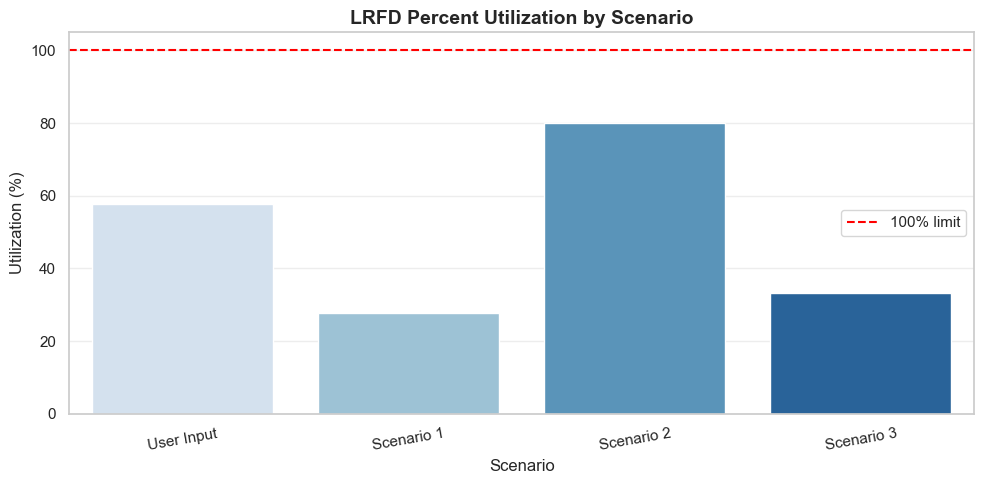

In [20]:
# LRFD utilization bar chart: each bar shows Pu / φPn as a percentage; red line marks the 100% pass/fail threshold
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results,
    x="Scenario",
    y="LRFD Utilization (%)",
    hue="Scenario",
    palette="Blues",
    legend=False
)
plt.axhline(100, color="red", linestyle="--", linewidth=1.5, label="100% limit")  # Bars above this line = FAIL
plt.xlabel("Scenario")
plt.ylabel("Utilization (%)")
plt.title("LRFD Percent Utilization by Scenario", fontsize=14, fontweight="bold")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

## ASD Utilization Chart

Bar chart of ASD percent utilization for each scenario. The red dashed line marks the 100% limit — bars above this line indicate a failing member under ASD.

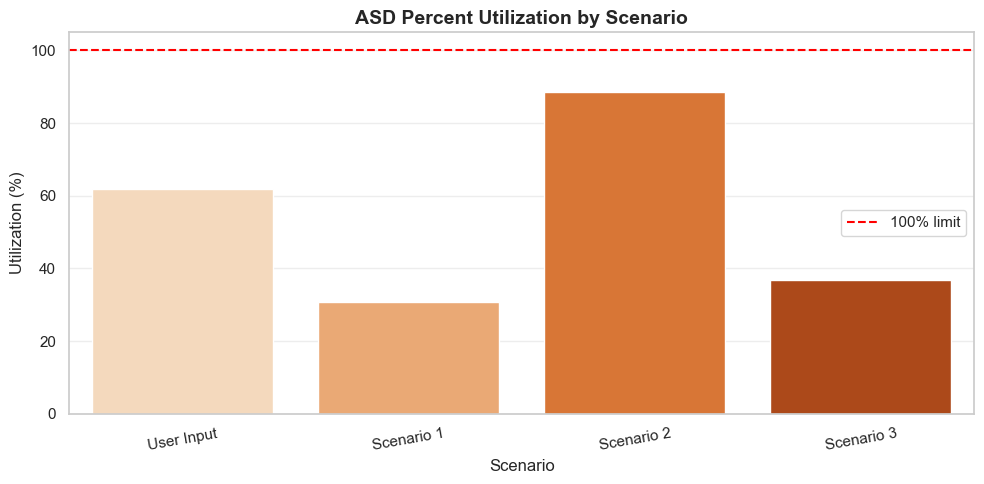

In [21]:
# ASD utilization bar chart: each bar shows Pa / (Pn/Ω) as a percentage; red line marks the 100% pass/fail threshold
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results,
    x="Scenario",
    y="ASD Utilization (%)",
    hue="Scenario",
    palette="Oranges",
    legend=False
)
plt.axhline(100, color="red", linestyle="--", linewidth=1.5, label="100% limit")  # Bars above this line = FAIL
plt.xlabel("Scenario")
plt.ylabel("Utilization (%)")
plt.title("ASD Percent Utilization by Scenario", fontsize=14, fontweight="bold")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()